#Análisis exploratorio dataset Telco Customer Churn

Limpieza y estandarización desde BigQuery

## Autenticar cuenta google

In [ ]:
from google.colab import auth
auth.authenticate_user()
print("Autenticado")

Autenticado


## Carga telco_clean directo desde BigQuery a un DataFrame

In [ ]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="skydrop-prep")

query = "SELECT * FROM `skydrop-prep.skydropx.telco_clean`"
df = client.query(query).to_dataframe()

print(df.shape)   # esperado: 7043 filas, 21 columnas
df.head(5)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges
0,9426-SXNHE,Female,0,False,False,2,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Bank transfer (automatic),18.75,False,53.15
1,3806-YAZOV,Female,0,False,False,3,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,False,56.00
2,3387-PLKUI,Female,0,True,True,13,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,False,251.25
3,8992-CEUEN,Female,0,False,False,1,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Electronic check,18.85,False,18.85
4,0620-XEFWH,Male,0,True,True,4,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.85,False,84.20


## EDA telco_clean

Churn
False    0.73463
True     0.26537
Name: proportion, dtype: Float64


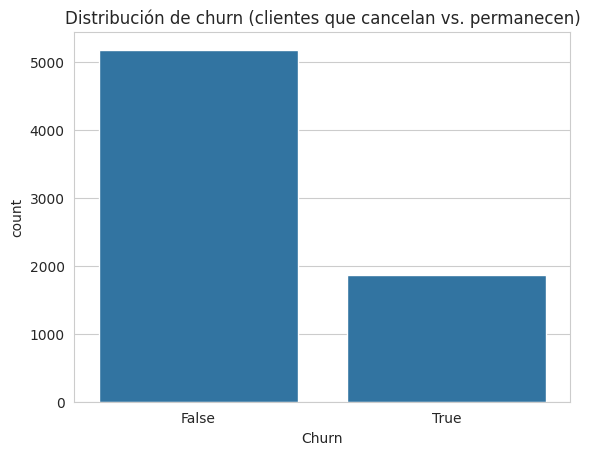

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Tasa de churn global
churn_rate = df['Churn'].value_counts(normalize=True)
print(churn_rate)

sns.countplot(data=df, x='Churn')
plt.title('Distribución de churn (clientes que cancelan vs. permanecen)')
plt.show()

El 26% de los clientes cancelan, esta es la base para los demás resultados.

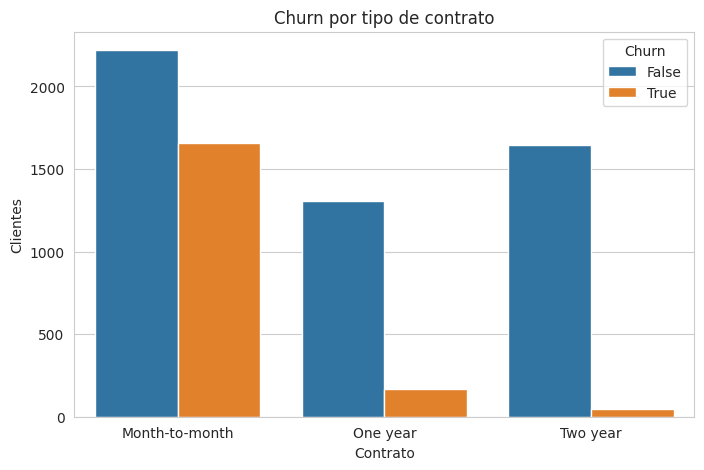

Contract
Month-to-month    0.0
One year          0.0
Two year          0.0
Name: Churn, dtype: float64


In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn por tipo de contrato')
plt.xlabel('Contrato'); plt.ylabel('Clientes')
plt.show()

# Tasa de churn por contrato
print(df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).round(3))

El tipo de contrato mes a mes tiene mas churn que los contratos de uno y dos años, siendo este el factor predominante.

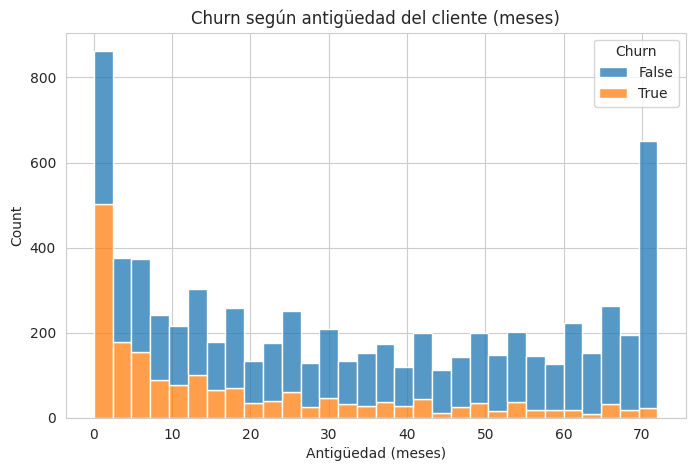

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn según antigüedad del cliente (meses)')
plt.xlabel('Antigüedad (meses)')
plt.show()

El churn esta dado en los primeros meses, los clientes nuevos se van más.

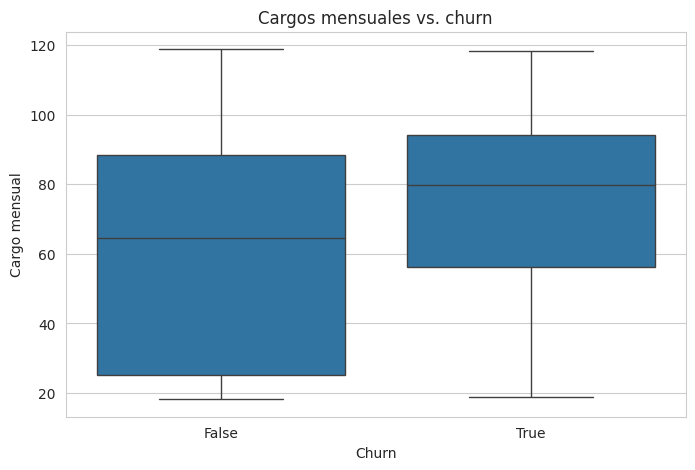

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Cargos mensuales vs. churn')
plt.ylabel('Cargo mensual')
plt.show()

Quienes cancelan tienden a tener cargos mensuales más altos, siendo este de 80.

## Resumen de hallazgos


1. Churn global ~26%.
2. Contrato month-to-month = principal predictor de cancelación.
3. El churn se concentra en clientes nuevos (baja antigüedad).
4. Cargos mensuales altos se asocian con mayor cancelación.

Recomendación: reforzar el onboarding y adaptabilidad del cliente para la permanencia.